## Student Performance Indicator

#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame


In [3]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [5]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check duplicated

In [7]:
print(df.duplicated().sum())

0


#### There are no duplicate values

### 3.3 Check data types

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Check for unique values in relevant columns

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
df[['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']].nunique()

gender                         2
race_ethnicity                 5
parental_level_of_education    6
lunch                          2
test_preparation_course        2
dtype: int64

### 3.5 Check statistics of dataset

In [11]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading = 17

### 3.6 Checking various categories of categorical data

In [14]:
# Making categorical and numerical features
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'str']
numerical_features=[feature for feature in df.columns if df[feature].dtype != 'str']

print(f"We have {len(categorical_features)} categorical features: {categorical_features}")
print(f"{len(numerical_features)} numerical features: {numerical_features}")

We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
3 numerical features: ['math_score', 'reading_score', 'writing_score']


In [13]:
print("List of categorical data along with the categories: ")
print(50*"=")
for category in categorical_features:
    print(f"{category}: {df[category].unique().tolist()}")

List of categorical data along with the categories: 
gender: ['female', 'male']
race_ethnicity: ['group B', 'group C', 'group A', 'group D', 'group E']
parental_level_of_education: ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
lunch: ['standard', 'free/reduced']
test_preparation_course: ['none', 'completed']


### 3.7 Adding total marks and average marks

In [15]:
df['total_marks'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_marks'] = df['total_marks']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_marks,average_marks
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [20]:
full_maths = df[df['math_score'] == 100]['average_marks'].count()
full_reading = df[df['reading_score'] == 100]['average_marks'].count()
full_writing = df[df['writing_score'] == 100]['average_marks'].count()

print(f"Number of students with full marks in maths: {full_maths}")
print(f"Number of students with full marks in reading: {full_reading}")
print(f"Number of students with full marks in writing: {full_writing}")

Number of students with full marks in maths: 7
Number of students with full marks in reading: 17
Number of students with full marks in writing: 14


In [22]:
reading_less_20 = df[df['reading_score'] <= 20]['average_marks'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average_marks'].count()
math_less_20 = df[df['math_score'] <= 20]['average_marks'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

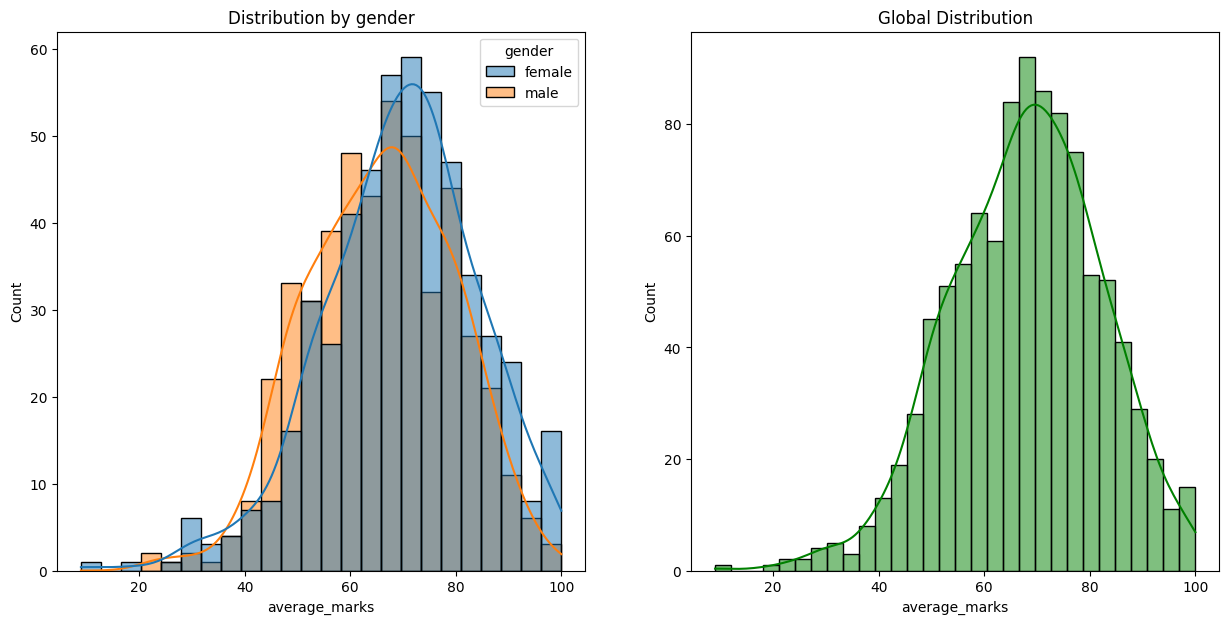

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(122)
sns.histplot(data=df,x='average_marks',bins=30,kde=True,color='g')
plt.title('Global Distribution')
plt.subplot(121)
sns.histplot(data=df,x='average_marks',kde=True,hue='gender')
plt.title('Distribution by gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

##### Analysis of Student Performance by Gender and Lunch Type

Text(0.5, 1.0, 'Male students')

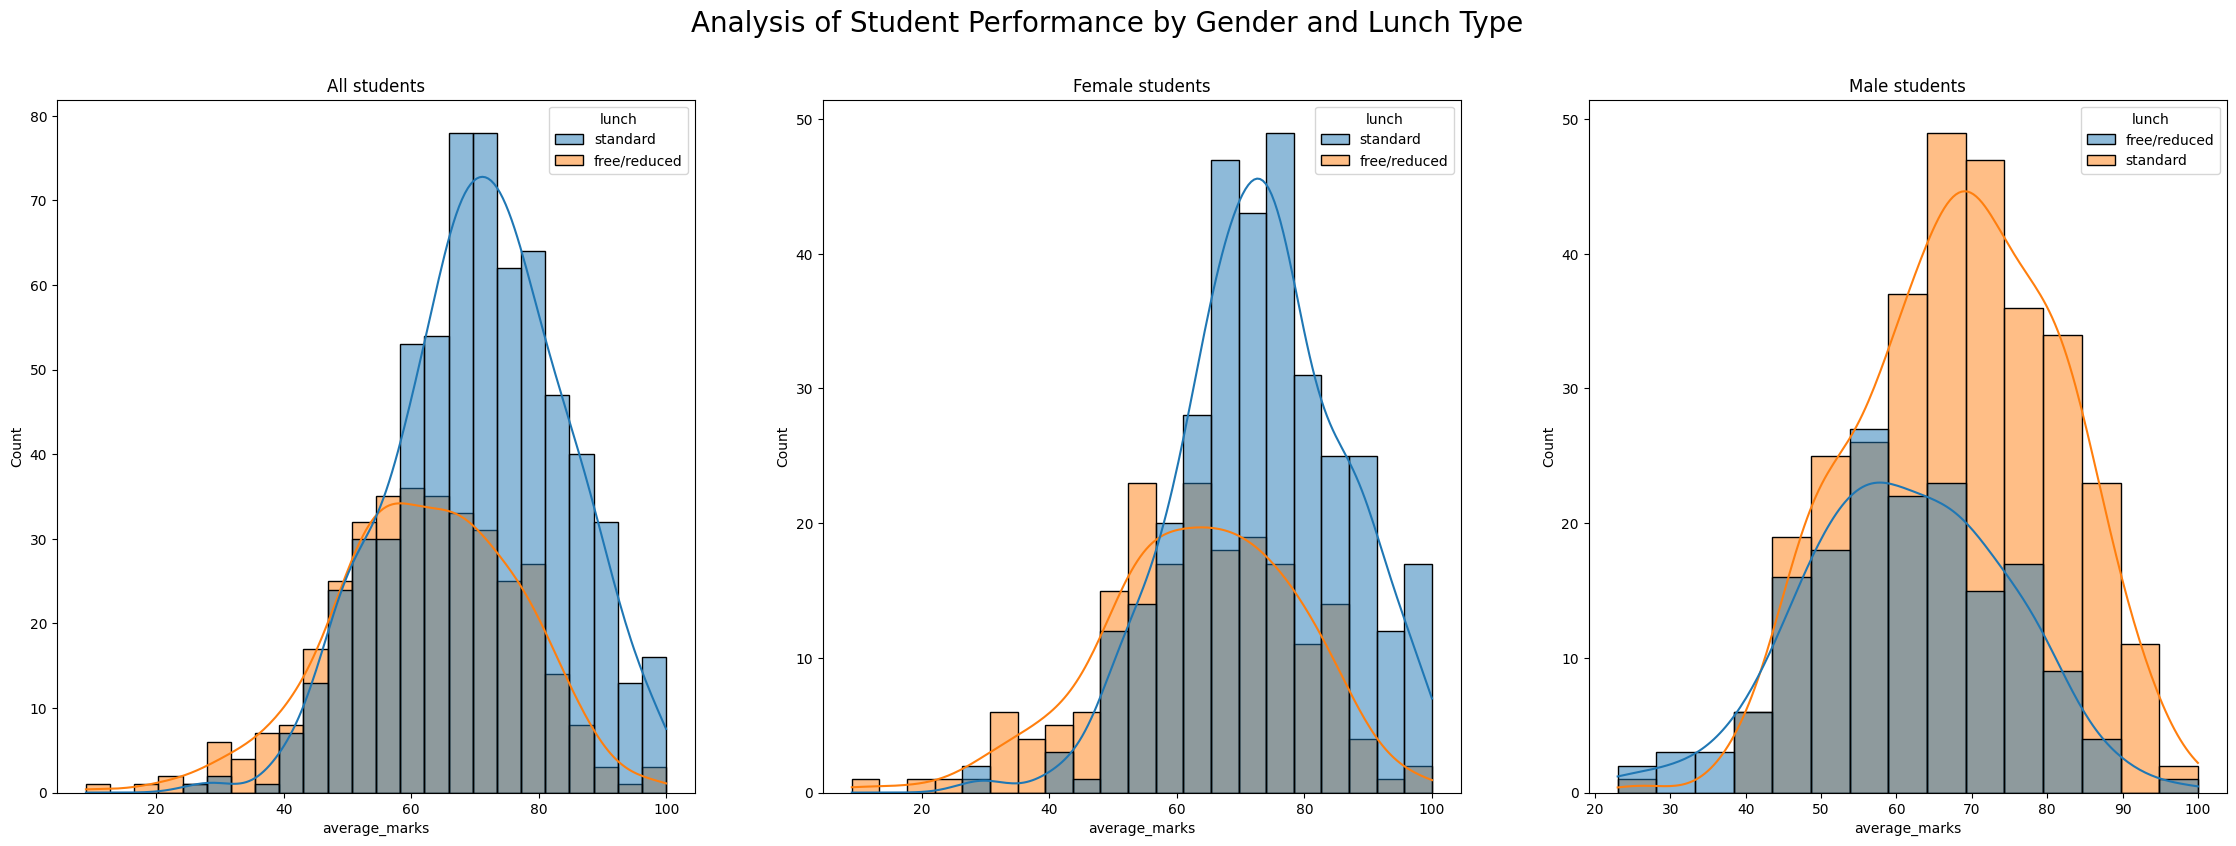

In [47]:
fig, axs = plt.subplots(1, 3, figsize=(28, 9))
fig.suptitle('Analysis of Student Performance by Gender and Lunch Type', fontsize=20)

# Plot 1: Effect of lunch on student's performance.
sns.histplot(data=df, x='average_marks', kde=True, hue='lunch', ax=axs[0])
axs[0].set_title("All students")

# Plot 2: Effect of lunch on female student's performance
sns.histplot(data=df[df['gender'] == 'female'], x='average_marks', kde=True, hue='lunch', ax=axs[1])
axs[1].set_title('Female students')

#Plot 3: Effect of lunch on male student's performance
sns.histplot(data=df[df['gender'] == 'male'], x='average_marks', kde=True, hue='lunch', ax=axs[2])
axs[2].set_title('Male students')

#### Insights
- A quality lunch plays an important role in a student's performance regardless of their gender.

##### Analysis of student performance based on their parent's education

Text(0.5, 1.0, 'Male students')

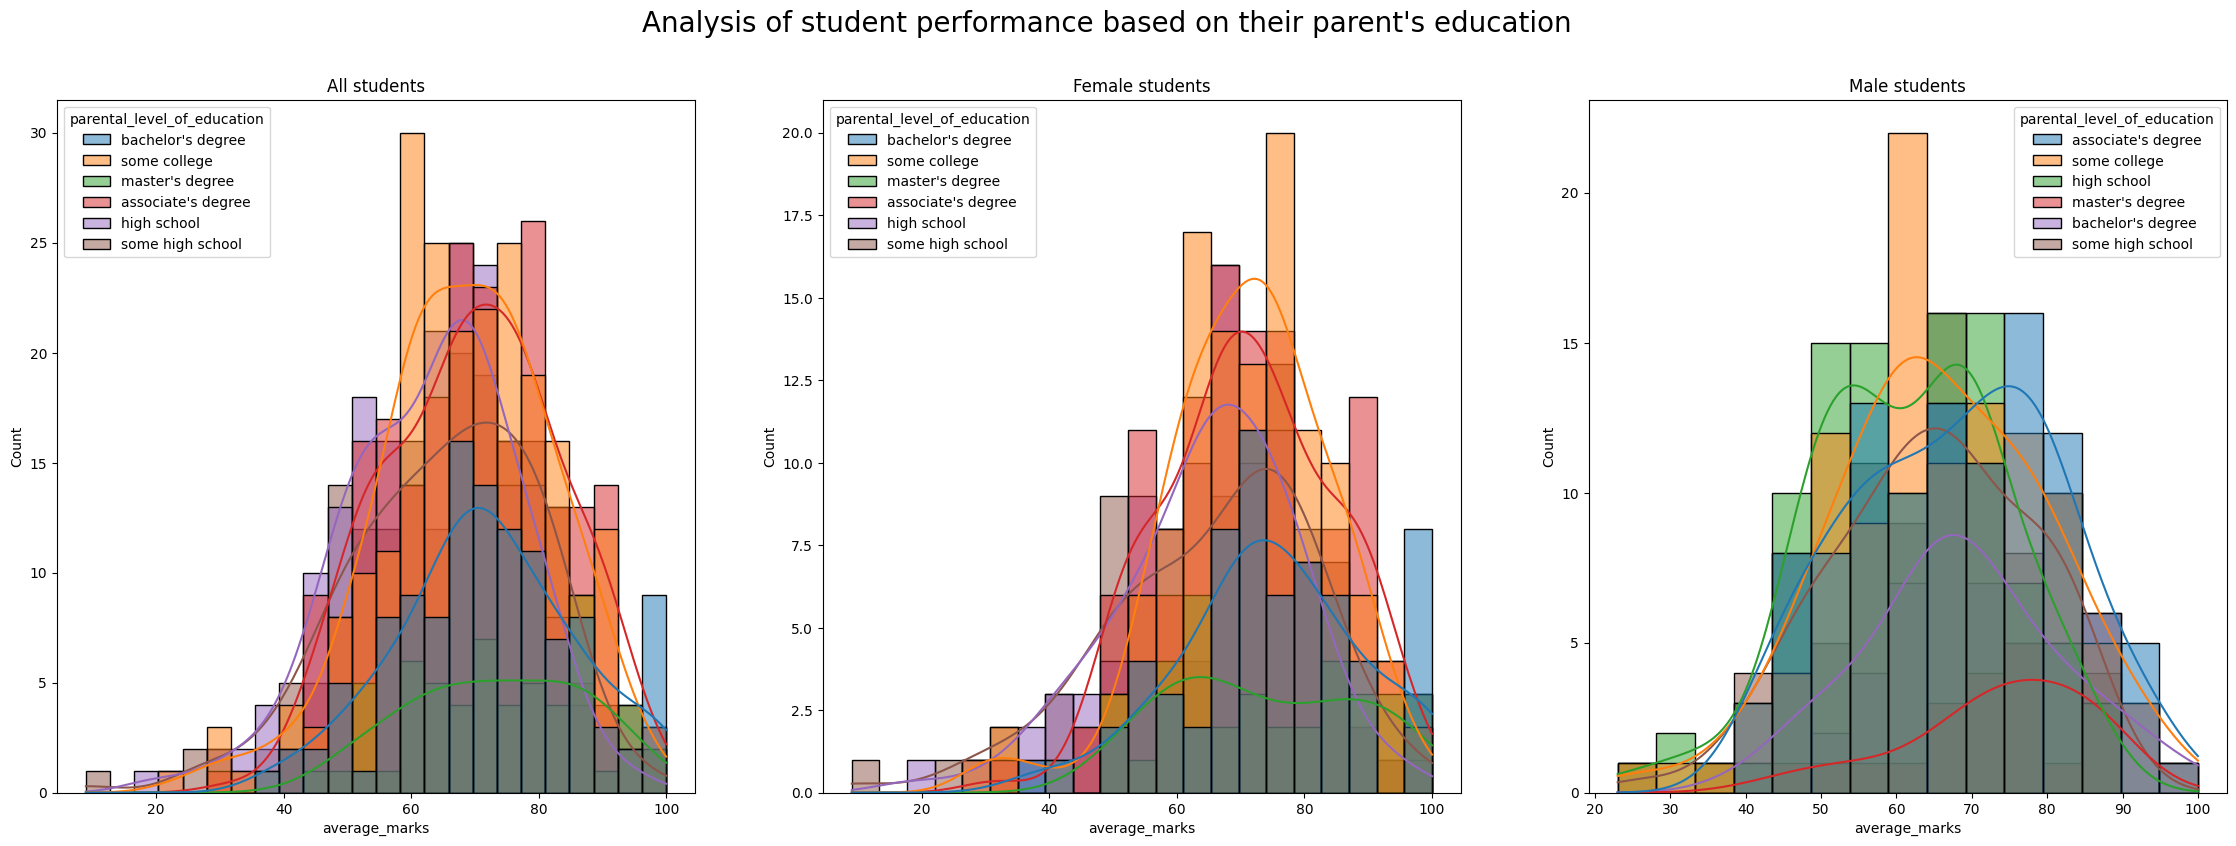

In [52]:
fig, axs = plt.subplots(1, 3, figsize=(28,9))
fig.suptitle("Analysis of student performance based on their parent's education", fontsize=20)

# Plot 1: Effect of parent's background on all students
sns.histplot(data=df, x='average_marks', kde=True, hue='parental_level_of_education', ax=axs[0])
axs[0].set_title('All students')

# Plot 2: Effect of parent's background on females
sns.histplot(data=df[df.gender == 'female'], x='average_marks', kde=True, hue='parental_level_of_education', ax=axs[1])
axs[1].set_title('Female students')

# Plot 3: Effect of parent's background on Males
sns.histplot(data=df[df.gender == 'male'], x='average_marks', kde=True, hue='parental_level_of_education', ax=axs[2])
axs[2].set_title('Male students')

The analysis seems a tough job through this spaghetti of colours so we switch to -- BOXPLOT for clarity

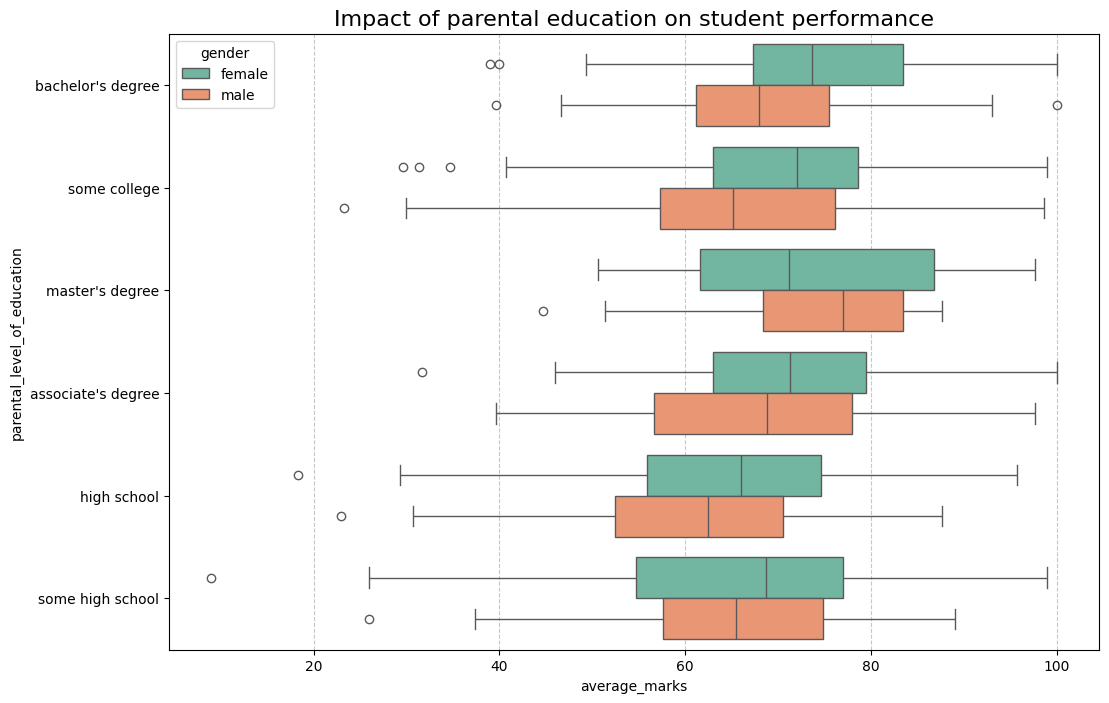

In [57]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=df, x='average_marks', y='parental_level_of_education', hue='gender', palette='Set2')

plt.title("Impact of parental education on student performance", fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


Although we have gained some insights about effects of parent's education on children's score I think we need further investigation to make any solid claims.
Now we will be using heatmaps in order to understand the correlation between parent's education and student's performance.

In [59]:
# We will add an ordinally encoded parent's education column in order to use the visualization resources in a better way.
parents_education = df['parental_level_of_education'].unique().tolist()
print(parents_education)
parents_education_map = {
    'some high school': 1,
    'high school': 2,
    'some college': 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}

# Applying the encoding
df['parental_level_of_education_encoded'] = df['parental_level_of_education'].map(parents_education_map)
df.head()

["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_marks,average_marks,parental_level_of_education_encoded
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,5
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,3
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,6
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,4
4,male,group C,some college,standard,none,76,78,75,229,76.333333,3


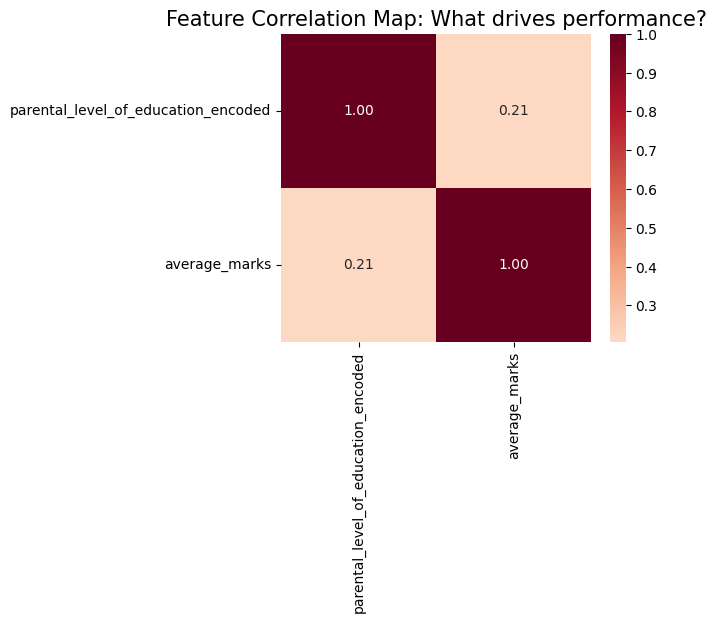

In [61]:
cols_to_compare = ['parental_level_of_education_encoded', 'average_marks']
corr_matrix = df[cols_to_compare].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Feature Correlation Map: What drives performance?', fontsize=15)
plt.show()

##### Insights
- The correlation is too low so we can tell that there is no significant effect of parent's education on ward's performance

##### Analysis of Student's performance based on their ethnicity or race

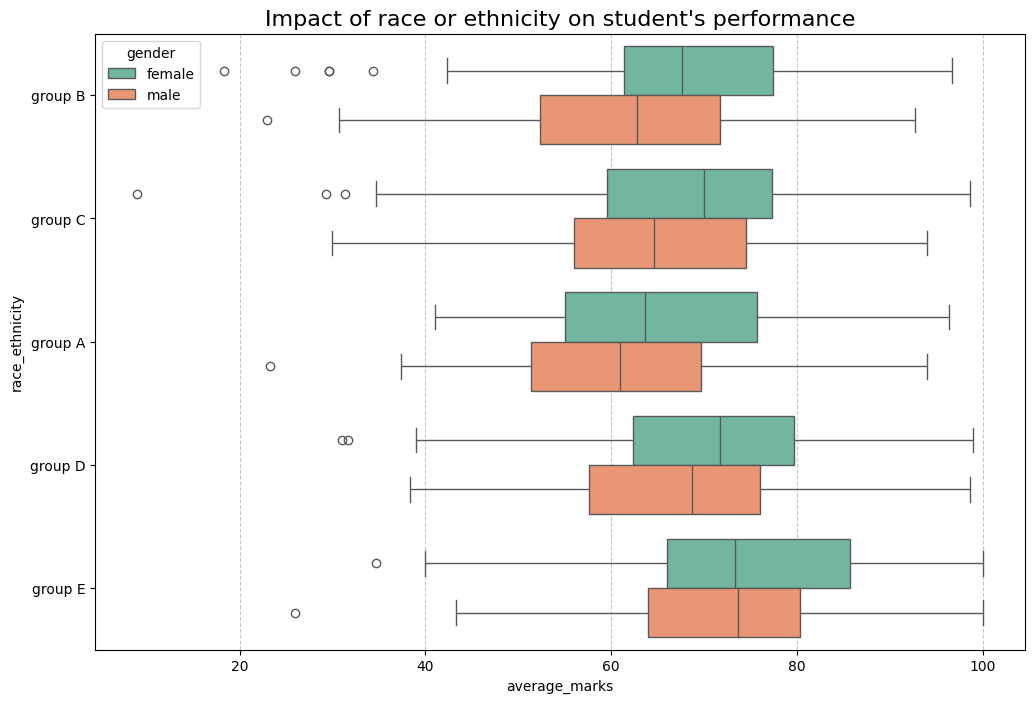

In [63]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df, x='average_marks', y='race_ethnicity', hue='gender', palette='Set2')

plt.title("Impact of race or ethnicity on student's performance", fontsize=16)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

##### Insights
- We can notice that there are no significance difference due to race_ethnicity criteria.

#### 4.2 Maximumum score of students in all three subjects

Text(0.5, 1.0, 'Writing score')

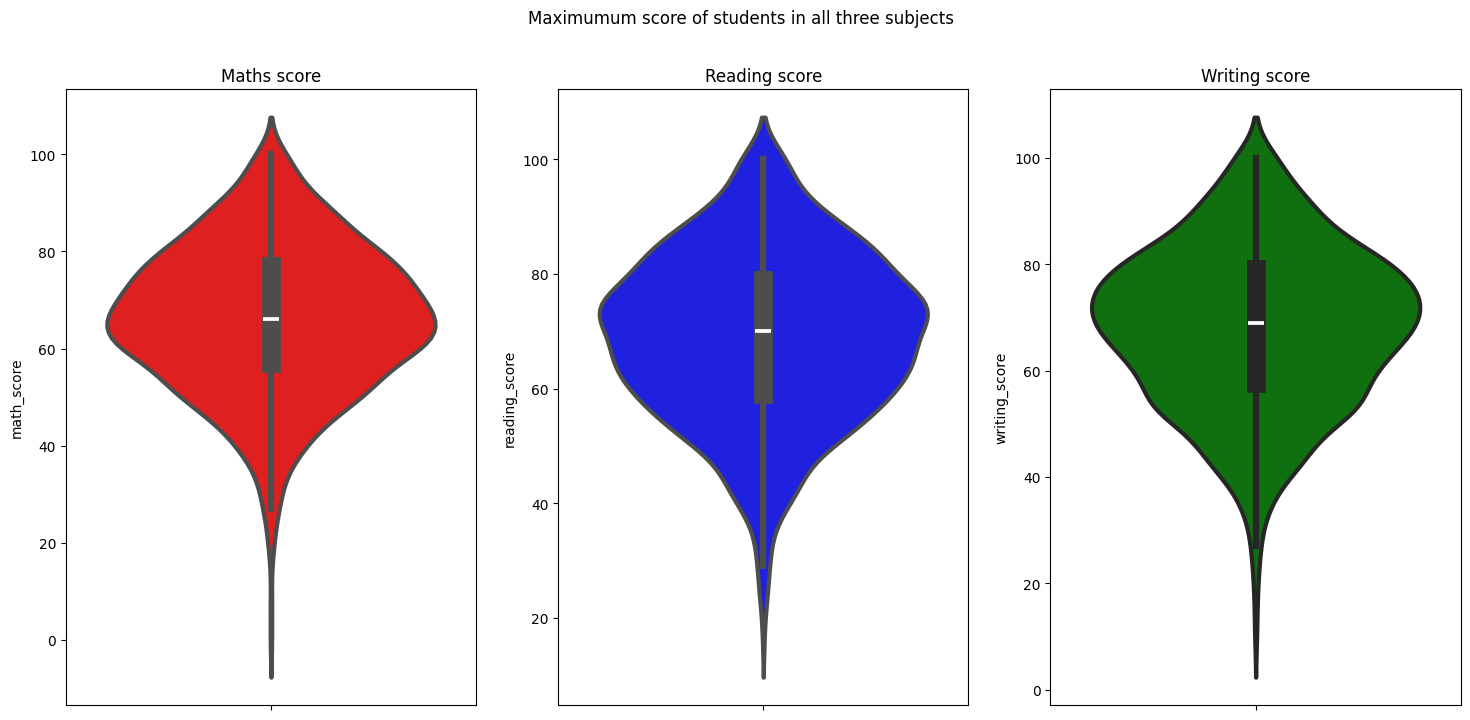

In [64]:
fig, axs = plt.subplots(1, 3, figsize=(18,8))
fig.suptitle("Maximumum score of students in all three subjects")

# Plot 1: Maths
sns.violinplot(data=df, y='math_score', color='red', linewidth=3, ax=axs[0])
axs[0].set_title("Maths score")

# Plot 2: Reading
sns.violinplot(data=df, y='reading_score', color='blue', linewidth=3, ax=axs[1])
axs[1].set_title("Reading score")

# Plot 3: Writing
sns.violinplot(data=df, y='writing_score', color='green', linewidth=3, ax=axs[2])
axs[2].set_title("Writing score")

#### 4.3 Multivariate analysis using pieplot

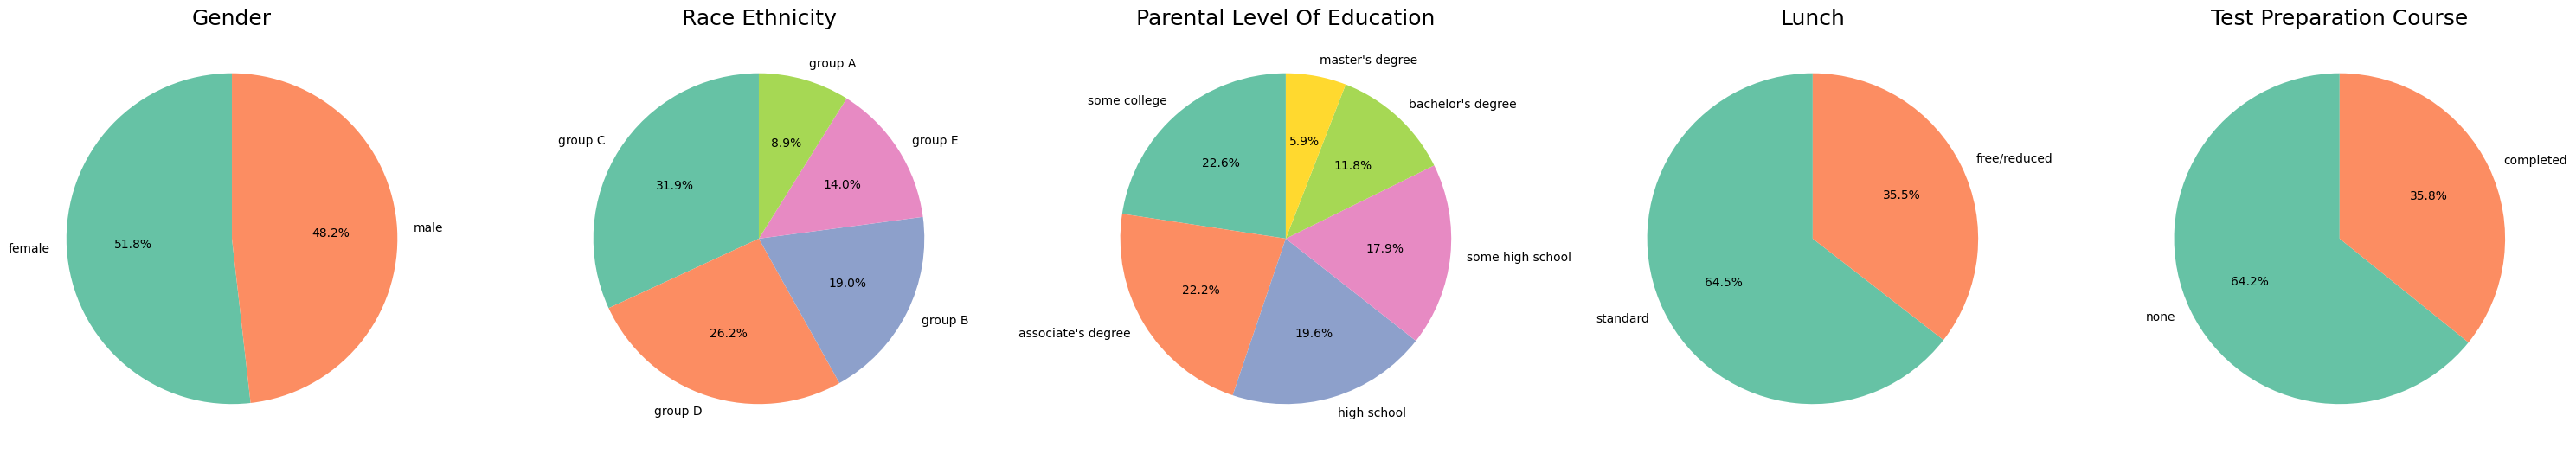

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(30, 10))

for i, feature in enumerate(categorical_features):
    size = df[feature].value_counts()
    label_names = size.index
    
    axs[i].pie(size, labels = label_names, autopct = '%1.1f%%', startangle = 90, colors = sns.color_palette('Set2'))
    axs[i].set_title(feature.replace('_', ' ').title(), fontsize = 18)   
plt.tight_layout()
plt.show()   

We can see that there is a lot of clutter in categories Race/Ethnicity and Parental Level Of Education.
So we will use countplot to gain a better understanding of the data.

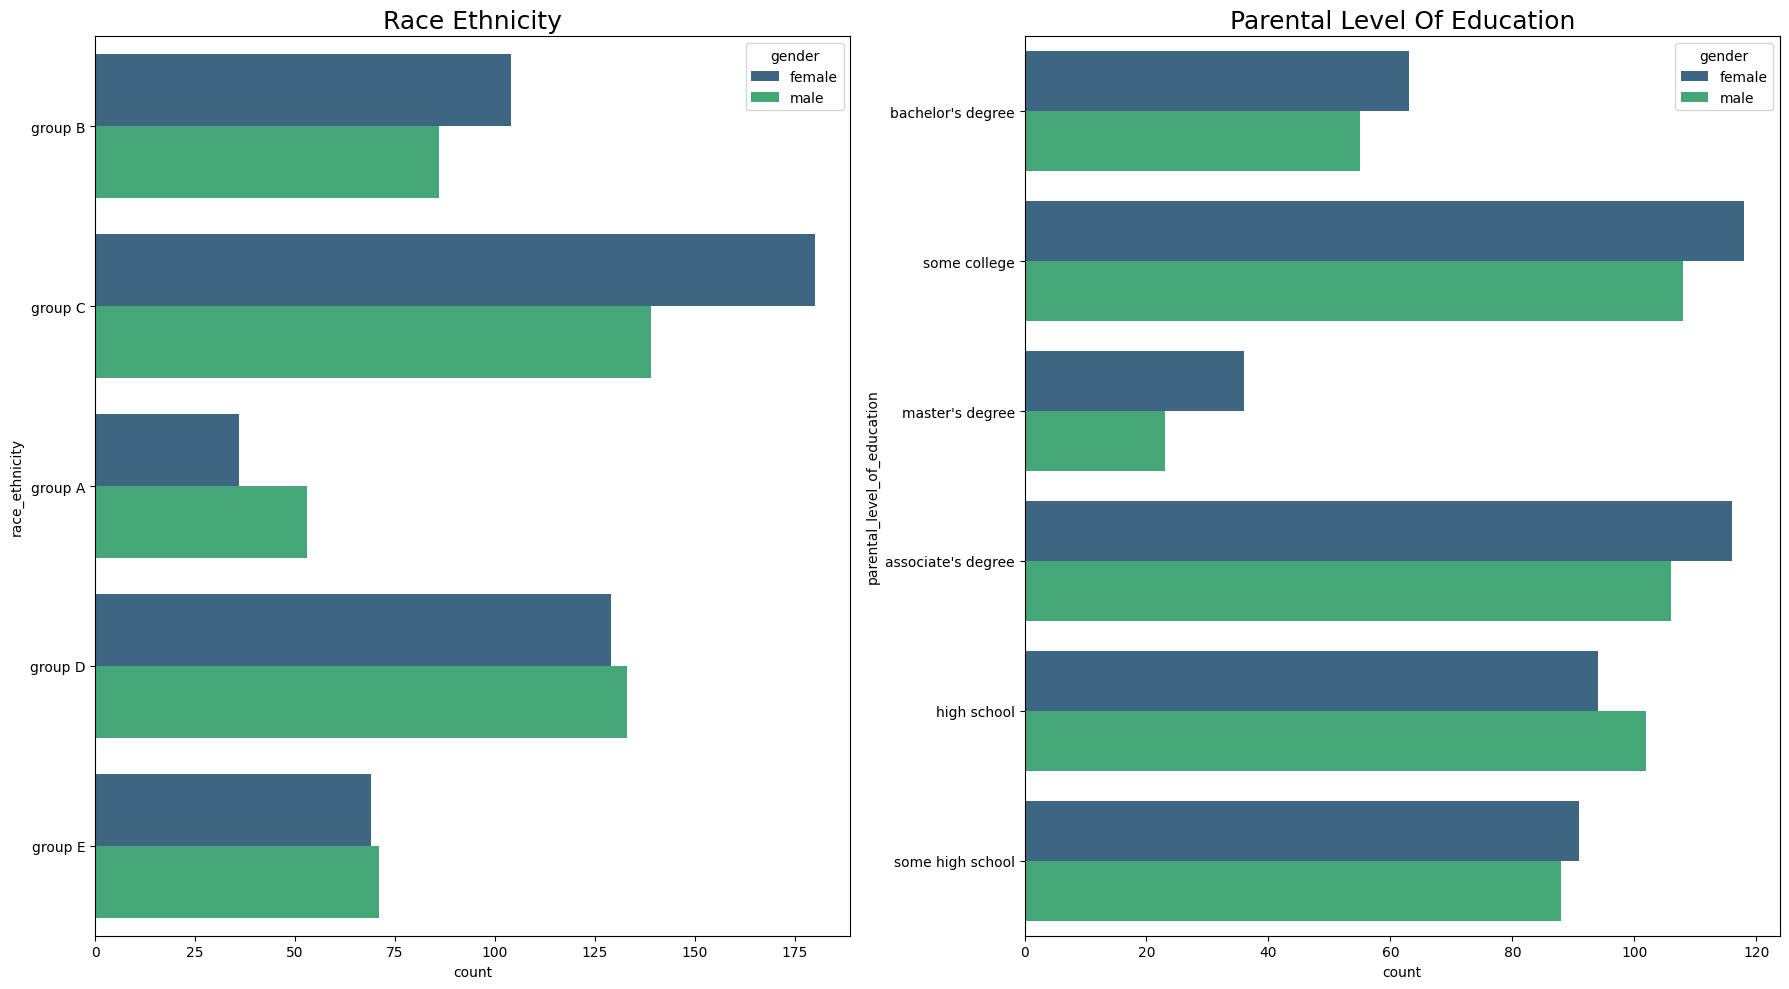

In [80]:
features = ['race_ethnicity', 'parental_level_of_education']

fig, axs = plt.subplots(1, 2, figsize=(18, 10))

for i, feature in enumerate(features):
    sns.countplot(data=df, y=feature, hue='gender', palette='viridis', ax=axs[i])
    axs[i].set_title(feature.replace('_', ' ').title(), fontsize=18)
plt.tight_layout()
plt.show()

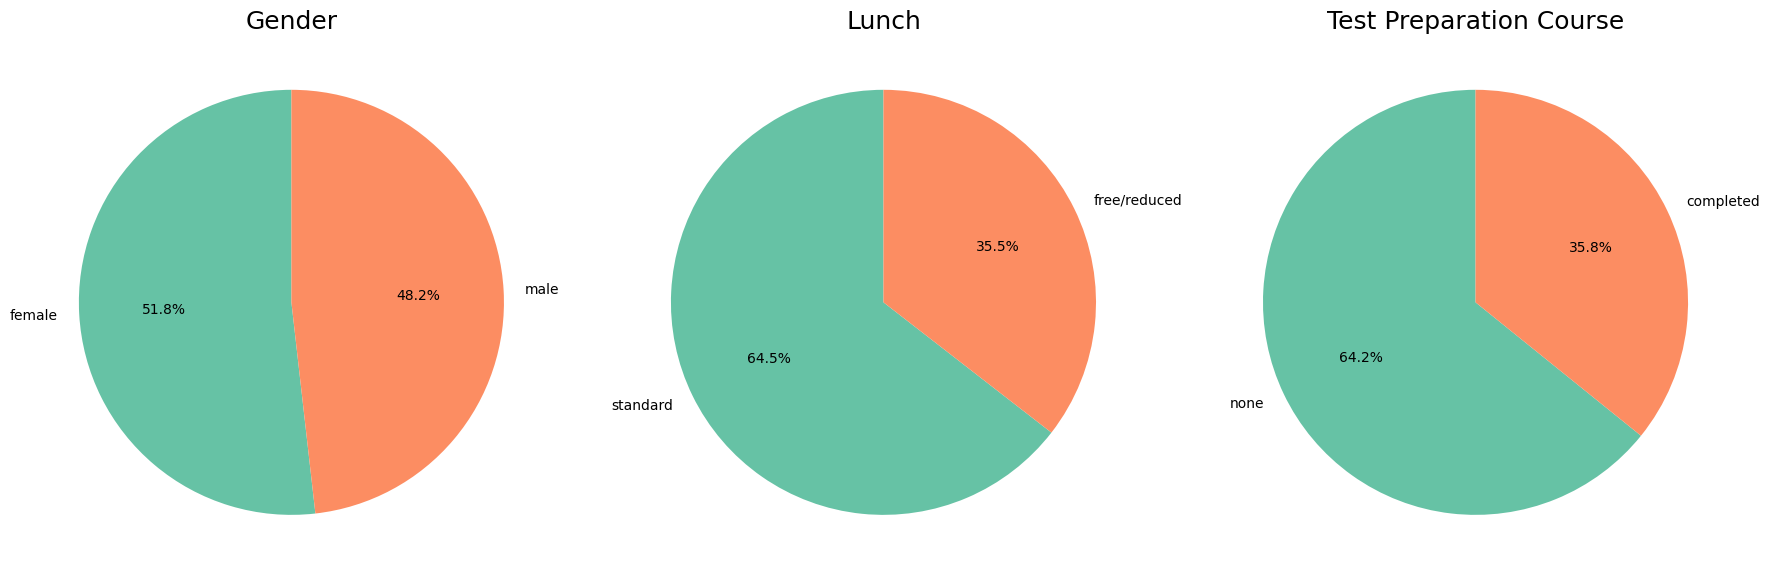

In [85]:
features = ['gender', 'lunch', 'test_preparation_course']
fig, axs = plt.subplots(1, 3, figsize=(18, 10))

for i, feature in enumerate(features):
    size = df[feature].value_counts()
    label_names = size.index
    
    axs[i].pie(size, labels = label_names, autopct = '%1.1f%%', startangle = 90, colors = sns.color_palette('Set2'))
    axs[i].set_title(feature.replace('_', ' ').title(), fontsize = 18)   
plt.tight_layout()
plt.show() 

#####  Insights
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### 4.4.2 RACE/EHNICITY COLUMN
- Is Race/Ehnicity has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

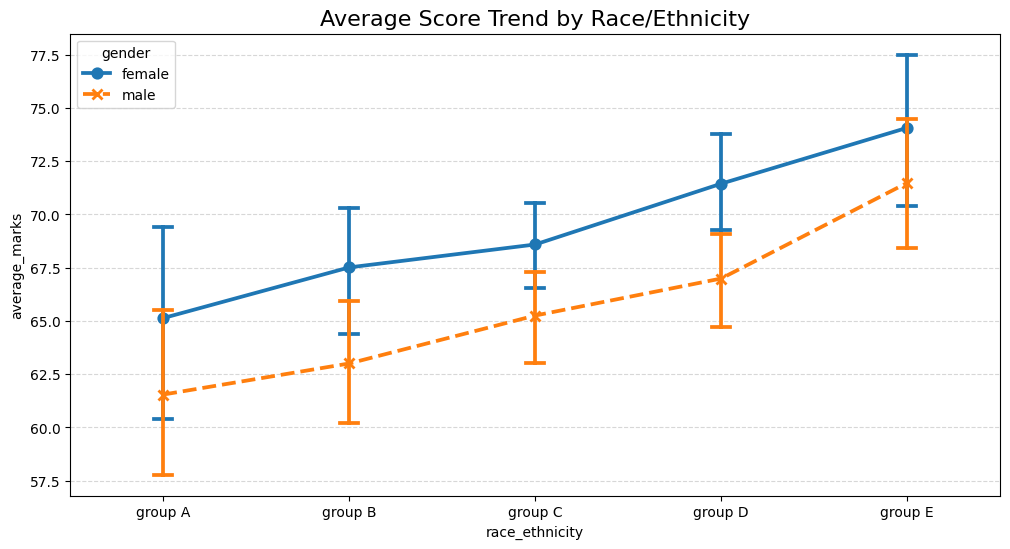

In [92]:
plt.figure(figsize=(12, 6))

# Pointplot is excellent for showing 'Rank' and 'Trend' across categories
sns.pointplot(data=df, x='race_ethnicity', y='average_marks', hue='gender', capsize=.1,
              order=['group A', 'group B', 'group C', 'group D', 'group E'],
              markers=["o", "x"], linestyles=["-", "--"])

plt.title('Average Score Trend by Race/Ethnicity', fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.